# A small decoder-only language model

We now assemble embeddings, positional embeddings, several decoder blocks, and a language-model head. The model is intentionally small enough to train on a short text sample and inspect end to end.

In [1]:
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.nn import functional as F
SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cpu


In [2]:
text = ('the quick brown fox jumps over the lazy dog. ' * 300).lower()
chars = sorted(set(text))
to_id = {c: i for i, c in enumerate(chars)}
from_id = {i: c for c, i in to_id.items()}
ids = torch.tensor([to_id[c] for c in text], dtype=torch.long)
cut = int(0.9 * len(ids))
train_ids, val_ids = (ids[:cut], ids[cut:])
context_length = 32

def windows(stream):
    x = torch.stack([stream[i:i + context_length] for i in range(len(stream) - context_length)])
    y = torch.stack([stream[i + 1:i + context_length + 1] for i in range(len(stream) - context_length)])
    return (x, y)
train_x, train_y = windows(train_ids)
val_x, val_y = windows(val_ids)
print(len(chars), train_x.shape, val_x.shape)

28 torch.Size([12118, 32]) torch.Size([1318, 32])


In [3]:
class MultiHeadAttention(nn.Module):

    def __init__(self, channels, heads, max_time):
        super().__init__()
        self.heads = heads
        self.head_size = channels // heads
        if channels % heads:
            raise ValueError('channels must be divisible by heads')
        self.query = nn.Linear(channels, channels, bias=False)
        self.key = nn.Linear(channels, channels, bias=False)
        self.value = nn.Linear(channels, channels, bias=False)
        self.output = nn.Linear(channels, channels)
        self.register_buffer('mask', torch.tril(torch.ones(max_time, max_time, dtype=torch.bool)))

    def forward(self, x):
        batch, time, channels = x.shape
        split = lambda t: t.view(batch, time, self.heads, self.head_size).transpose(1, 2)
        q, k, v = map(split, (self.query(x), self.key(x), self.value(x)))
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_size)
        scores = scores.masked_fill(~self.mask[:time, :time], float('-inf'))
        weights = torch.softmax(scores, dim=-1)
        output = weights @ v
        output = output.transpose(1, 2).contiguous().view(batch, time, channels)
        return (self.output(output), weights)

class DecoderBlock(nn.Module):

    def __init__(self, channels, heads, max_time):
        super().__init__()
        self.norm_attention = nn.LayerNorm(channels)
        self.attention = MultiHeadAttention(channels, heads, max_time)
        self.norm_feed_forward = nn.LayerNorm(channels)
        self.feed_forward = nn.Sequential(nn.Linear(channels, 4 * channels), nn.GELU(), nn.Linear(4 * channels, channels))

    def forward(self, x):
        attention_output, weights = self.attention(self.norm_attention(x))
        x = x + attention_output
        x = x + self.feed_forward(self.norm_feed_forward(x))
        return (x, weights)

class TinyDecoderLM(nn.Module):

    def __init__(self, vocabulary_size, context_length, channels=64, layers=2, heads=4):
        super().__init__()
        self.context_length = context_length
        self.token_embedding = nn.Embedding(vocabulary_size, channels)
        self.position_embedding = nn.Embedding(context_length, channels)
        self.blocks = nn.ModuleList([DecoderBlock(channels, heads, context_length) for _ in range(layers)])
        self.norm = nn.LayerNorm(channels)
        self.lm_head = nn.Linear(channels, vocabulary_size)

    def forward(self, token_ids, targets=None):
        batch, time = token_ids.shape
        positions = torch.arange(time, device=token_ids.device)
        x = self.token_embedding(token_ids) + self.position_embedding(positions)[None, :, :]
        for block in self.blocks:
            x, _ = block(x)
        logits = self.lm_head(self.norm(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        return (logits, loss)
model = TinyDecoderLM(len(chars), context_length).to(DEVICE)
print('parameters:', sum((p.numel() for p in model.parameters())))
print('output shape:', model(train_x[:4].to(DEVICE))[0].shape)

parameters: 105372
output shape: torch.Size([4, 32, 28])


## Training protocol

The same next-token objective appears again, now at every position in the context. We will report validation loss and perplexity, then sample from the trained model. The important trace is text → IDs → embeddings → blocks → logits → cross-entropy.

In [4]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003)
train_history = []
val_history = []
generator = torch.Generator().manual_seed(SEED)
for step in range(600):
    idx = torch.randint(len(train_x), (64,), generator=generator)
    x, y = (train_x[idx].to(DEVICE), train_y[idx].to(DEVICE))
    _, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    if step % 100 == 0:
        with torch.no_grad():
            _, vl = model(val_x[:512].to(DEVICE), val_y[:512].to(DEVICE))
        train_history.append(loss.item())
        val_history.append(vl.item())
print('final validation perplexity:', math.exp(val_history[-1]))

final validation perplexity: 1.0254254463366779


## The complete forward path

Token IDs are looked up in a learned token-embedding table. A position embedding tells the model where each token sits in the context. The sequence then passes through decoder blocks, a final normalization, and a linear language-model head. At every position the head produces one logit per vocabulary item, so the model can be trained against all next-token targets in parallel.

## Why the target has the same time length

For an input sequence of length `T`, the target sequence is shifted left by one position and also has length `T`. Position `t` predicts the token at `t+1`; the causal mask ensures that prediction cannot read tokens after `t`. This parallel training is equivalent to generation one token at a time, but much faster during optimization.

## Limits of this demonstration

The repeated pangram is useful for verifying the mechanics, not for measuring language ability. A real corpus would need provenance, cleaning rules, a held-out split, and a documented compute budget. The model architecture is now complete; the next notebooks study how training and decoding choices affect what it produces.

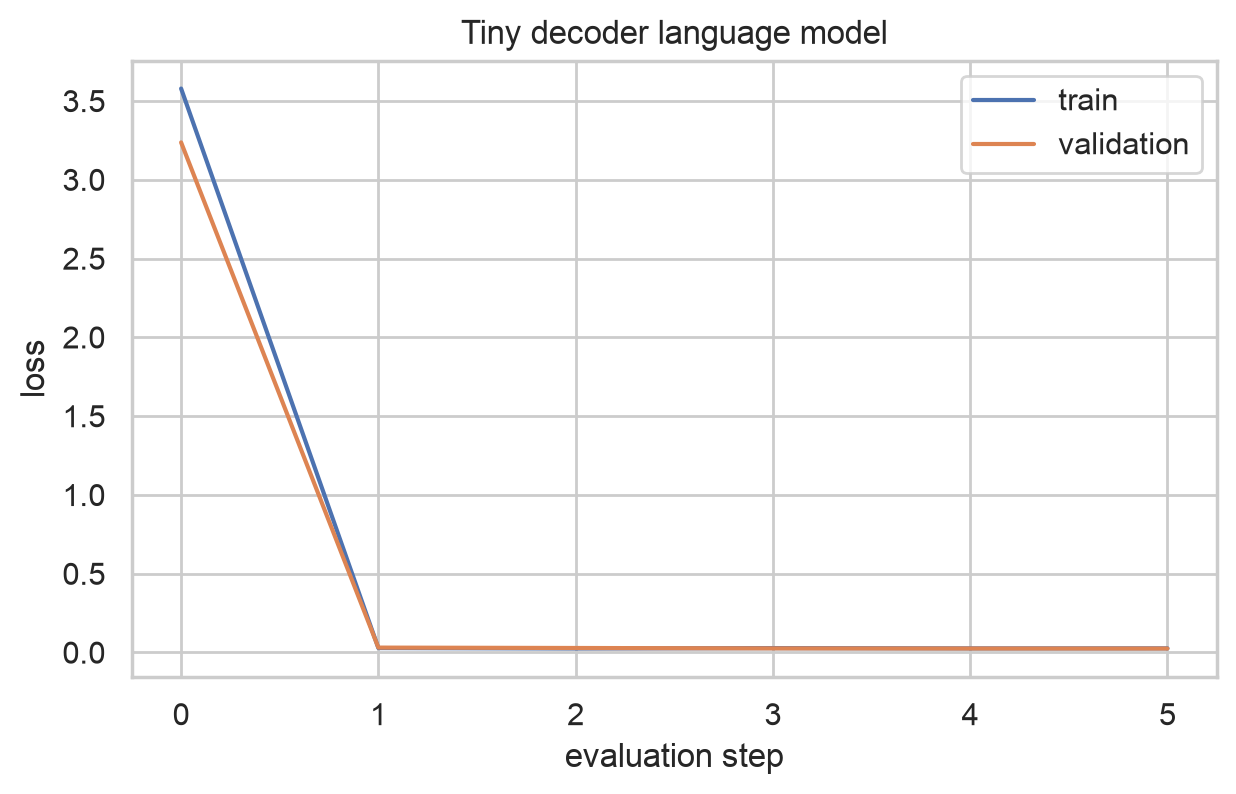

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(train_history, label='train')
plt.plot(val_history, label='validation')
plt.xlabel('evaluation step')
plt.ylabel('loss')
plt.title('Tiny decoder language model')
plt.legend()
plt.show()